In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path='/content/drive/MyDrive/project/SolarPanelSoilingImageDataset/Solar_Panel_Soiling_Image_dataset/PanelImages'



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/solar_project"
os.makedirs(PROJECT_PATH, exist_ok=True)

In [ ]:
# !pwd
# %cd /content/drive/MyDrive/project/SolarPanelSoilingImageDataset/Solar_Panel_Soiling_Image_dataset/
# # !ls
# !pwd
# %cd PanelImages
# !ls



In [ ]:
import os

dataset_path = "/content/drive/MyDrive/project/SolarPanelSoilingImageDataset/Solar_Panel_Soiling_Image_dataset/PanelImages"

image_files = os.listdir(dataset_path)

print(len(image_files))      # should be ~45000
# print(image_files[:5])       # just to see sample names


45832


In [ ]:
data_rows = []

for filename in image_files:
  part_after_L = filename.split("_L_")[1]
  power_loss = float(part_after_L.split("_I_")[0])


  image_path = os.path.join(dataset_path, filename)

  data_rows.append([image_path, power_loss])





In [ ]:

import random

random.seed(42)

random.shuffle(data_rows) #to shuffle the dataset images


print(data_rows[1:2])


[['/content/drive/MyDrive/project/SolarPanelSoilingImageDataset/Solar_Panel_Soiling_Image_dataset/PanelImages/solar_Wed_Jun_28_16__6__39_2017_L_0.660276601137_I_0.216635294118.jpg', 0.660276601137]]


In [ ]:
Totalsamples = len(data_rows)
train_size = int(0.7 * Totalsamples)
val_size   = int(0.2 * Totalsamples)
test_size  = Totalsamples - (train_size + val_size)

print('Totalsamples=',Totalsamples,',trainsize=',train_size,',valsize=',val_size,'test=',test_size,)

Totalsamples= 45832 ,trainsize= 32082 ,valsize= 9166 test= 4584


In [ ]:
Training=data_rows[ : train_size]
Validation=data_rows[train_size: train_size+ val_size]
Testing=data_rows[train_size+ val_size : ]


In [ ]:
import pandas as pd

train_df = pd.DataFrame(
    Training,
    columns=["image_path", "power_loss"]
)

val_df = pd.DataFrame(
    Validation,
    columns=["image_path", "power_loss"]   # avoid This is called data leakage.  If you train and repeatedly check on test data:
 )
                                                  #You unknowingly “memorize” test data

                                                #Test accuracy becomes fake

                                               # Model looks good but fails on real data


test_df = pd.DataFrame(
    Testing,
    columns=["image_path", "power_loss"]
)

# print(train_df.head())
# print(val_df.head())
# print(test_df.head())

print(len(train_df), len(val_df), len(test_df))



32082 9166 4584


In [ ]:
# import matplotlib.pyplot as plt
# from PIL import Image

# sample_image_path = test_df.iloc[0]["image_path"]
# sample_label = test_df.iloc[0]["power_loss"]

# print(sample_image_path)
# print("Power loss:", sample_label)



# img = Image.open(sample_image_path)

# plt.imshow(img)
# plt.title(f"Power loss: {sample_label}")
# plt.axis("off")


In [ ]:
# !pip install -U tensorflow

import tensorflow as tf

def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)  # 0–1 scaling
    return image, label

                                                                                    #read_file → reads image from disk                       # 🧠 Concept First (No Code Yet)
# sample_tensor, sample_label = load_and_preprocess_image(
#     sample_image_path,                                                            # decode_jpeg → converts to numeric matrix               #1)Take an image path
#     sample_label
# )                                                                                 # convert_image_dtype → normalization                    #2) Load the image

# print(sample_tensor.shape)                                                        # return → tensor + label                                #3)Convert it to a tensor
# print("Label:", sample_label)
                                                                                                                                           #4) Normalize it

                                                                                                                                           #5) Attach the label

                                                                                                                                           #6) Send it to the model in batches



In [ ]:
train_image_paths = train_df["image_path"].values

train_labels=train_df['power_loss'].values


train_ds = tf.data.Dataset.from_tensor_slices( (train_image_paths, train_labels) )    # Now we create a dataset that looks like:
                                                                                      # (image_path, label)  orooo image inum oro labels ayit slice chyt edukkn


train_ds = train_ds.map(load_and_preprocess_image,  num_parallel_calls=tf.data.AUTOTUNE)   # (image_tensor, label) calling the function


train_ds = train_ds.shuffle(buffer_size=1000)


BATCH_SIZE = 32
train_ds = train_ds.batch(BATCH_SIZE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)      # to increse speed , while processing load next batch








In [ ]:
Val_image_paths = val_df["image_path"].values

Val_labels=val_df['power_loss'].values

Val_ds = tf.data.Dataset.from_tensor_slices( (Val_image_paths, Val_labels) )

Val_ds = Val_ds.map(load_and_preprocess_image,  num_parallel_calls=tf.data.AUTOTUNE)

Val_ds = Val_ds.batch(BATCH_SIZE)

Val_ds = Val_ds.prefetch(tf.data.AUTOTUNE)



Test_image_paths = test_df["image_path"].values

Test_labels=test_df['power_loss'].values

Test_ds = tf.data.Dataset.from_tensor_slices( (Test_image_paths, Test_labels) )

Test_ds = Test_ds.map(load_and_preprocess_image,  num_parallel_calls=tf.data.AUTOTUNE)

Test_ds = Test_ds.batch(BATCH_SIZE)

Test_ds = Test_ds.prefetch(tf.data.AUTOTUNE)




# Transfer Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(192, 192, 3),
    include_top=False,   # Remove ImageNet labels
    weights="imagenet"
)

base_model.trainable = False

# model = models.Sequential([
#     base_model,
#     layers.GlobalAveragePooling2D(),
#     layers.Dense(64, activation="relu"),
#     layers.Dense(1)
# ])

# model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


“We freeze the pretrained MobileNet feature-extraction layers so their learned filters are reused without modification".

They encode patterns like:

edges

brightness changes

textures

repeated structures

output=∑(pixel values×filter weights)+bias


the keranl/filtters are done these
already trained to identify these  


Middle layers -  

In [ ]:
import numpy as np
feature_extractor = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D()
])

CHUNK_SIZE = 3000

# MAX_TRAIN = 3000
# MAX_VAL   = 800
# MAX_TEST  = 800

PROJECT_PATH = "/content/drive/MyDrive/solar_project"

TRAIN_DIR = f"{PROJECT_PATH}/train_features"
VAL_DIR   = f"{PROJECT_PATH}/val_features"
TEST_DIR  = f"{PROJECT_PATH}/test_features"



In [ ]:
def extract_and_save_features(data, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    total = len(data)
    for start in range(0, total, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, total)
        X_chunk, y_chunk = [], []

        for image_path, label in data[start:end]:
            img = tf.io.read_file(image_path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, (192, 192))
            img = tf.image.convert_image_dtype(img, tf.float32)
            img = tf.expand_dims(img, axis=0)

            features = feature_extractor(img)
            X_chunk.append(features.numpy()[0])
            y_chunk.append(label)

        X_chunk = np.array(X_chunk)
        y_chunk = np.array(y_chunk)

        np.save(os.path.join(save_dir, f"X_{start}_{end}.npy"), X_chunk)
        np.save(os.path.join(save_dir, f"y_{start}_{end}.npy"), y_chunk)

        print(f"Saved features: {start} to {end} → {save_dir}")



In [ ]:
print(type(feature_extractor))
print(CHUNK_SIZE)
print(TRAIN_DIR)


<class 'keras.src.models.sequential.Sequential'>
3000
/content/drive/MyDrive/solar_project/train_features


In [ ]:
extract_and_save_features(Training, TRAIN_DIR )



Saved features: 0 to 3000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 3000 to 6000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 6000 to 9000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 9000 to 12000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 12000 to 15000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 15000 to 18000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 18000 to 21000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 21000 to 24000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 24000 to 27000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 27000 to 30000 → /content/drive/MyDrive/solar_project/train_features
Saved features: 30000 to 32082 → /content/drive/MyDrive/solar_project/train_features


In [ ]:
extract_and_save_features(Validation, VAL_DIR)

Saved features: 0 to 3000 → /content/drive/MyDrive/solar_project/val_features
Saved features: 3000 to 6000 → /content/drive/MyDrive/solar_project/val_features
Saved features: 6000 to 9000 → /content/drive/MyDrive/solar_project/val_features
Saved features: 9000 to 9166 → /content/drive/MyDrive/solar_project/val_features


In [ ]:
extract_and_save_features(Testing, TEST_DIR)

Saved features: 0 to 3000 → /content/drive/MyDrive/solar_project/test_features
Saved features: 3000 to 4584 → /content/drive/MyDrive/solar_project/test_features


In [ ]:
def load_features(folder):
    X_list, y_list = [], []
    for file in sorted(os.listdir(folder)):
        if file.startswith("X_"):
            X_list.append(np.load(os.path.join(folder, file)))
        elif file.startswith("y_"):
            y_list.append(np.load(os.path.join(folder, file)))
    return np.vstack(X_list), np.hstack(y_list)

X_train, y_train = load_features(f"{PROJECT_PATH}/train_features")
X_val, y_val     = load_features(f"{PROJECT_PATH}/val_features")
X_test, y_test   = load_features(f"{PROJECT_PATH}/test_features")

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

# (32082, 1280)

# (9166, 1280)

# (4584, 1280)



(32082, 1280) (32082,)
(9166, 1280) (9166,)
(4584, 1280) (4584,)


In [ ]:
reg_model = tf.keras.Sequential([
    tf.keras.Input(shape=(1280,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])



In [ ]:
reg_model.compile(
    optimizer="adam",
    loss="mean_absolute_error",
    metrics=["mean_absolute_error"]
)



In [ ]:
history = reg_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64
)



Epoch 1/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1526 - mean_absolute_error: 0.1526 - val_loss: 0.0773 - val_mean_absolute_error: 0.0773
Epoch 2/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0754 - mean_absolute_error: 0.0754 - val_loss: 0.0645 - val_mean_absolute_error: 0.0645
Epoch 3/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0671 - mean_absolute_error: 0.0671 - val_loss: 0.0618 - val_mean_absolute_error: 0.0618
Epoch 4/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0602 - mean_absolute_error: 0.0602 - val_loss: 0.0644 - val_mean_absolute_error: 0.0644
Epoch 5/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0591 - mean_absolute_error: 0.0591 - val_loss: 0.0608 - val_mean_absolute_error: 0.0608
Epoch 6/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0563 - mean_absolute_error: 0.0563 - val_loss: 0.0579 - val_mean_absolute_error: 0.0579
Epoch 7/20
502/502 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0558 - mean_absolute_error: 0.0558 - v

In [ ]:
ttest_loss, test_mae = reg_model.evaluate(X_test, y_test)
print("Final Test MAE:", test_mae)


144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0476 - mean_absolute_error: 0.0476
Final Test MAE: 0.0485529899597168


In [ ]:
MODEL_PATH="/content/drive/MyDrive/solar_project/power_loss_model.keras"

reg_model.save(MODEL_PATH)



In [ ]:
!zip -r power_loss_model.zip /content/drive/MyDrive/solar_project/power_loss_model.keras

  adding: content/drive/MyDrive/solar_project/power_loss_model.keras (deflated 20%)


In [ ]:
from tensorflow.keras.models import load_model

reg_model = load_model("/content/drive/MyDrive/solar_project/power_loss_model.keras")


In [ ]:
#  this code was before the fast learning approch
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss="mean_absolute_error",
#     metrics=["mean_absolute_error"]
# )



In [ ]:
# history = model.fit(
#     train_ds,
#     validation_data=Val_ds,
#     epochs=10
# )


DATASET 2


In [ ]:
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/project/De-Solar Dataset-selected"
CROPPED_PATH = os.path.join(BASE_PATH, "Cropped_Folder/Cropped_Folder")
OUTPUT_CSV = os.path.join(BASE_PATH, "dataset_index.csv")

DEFECT_TYPES = ["Branch", "Dirt", "Droppings", "Leaves"]
FOLDS = ["fold1", "fold2", "fold3", "fold4", "fold5"]

rows = []

for defect in DEFECT_TYPES:
    print(f"\n🔍 Processing defect: {defect}")

    for fold in FOLDS:
        img_dir = os.path.join(CROPPED_PATH, defect, "img_dir", fold)
        ann_dir = os.path.join(CROPPED_PATH, defect, "ann_dir", fold)

        if not os.path.exists(img_dir) or not os.path.exists(ann_dir):
            continue

        for img_name in os.listdir(img_dir):
            if not img_name.lower().endswith(".png"):
                continue

            img_path = os.path.join(img_dir, img_name)

            # ---- FIX: build mask name ----
            base = os.path.splitext(img_name)[0]
            mask_name = f"{base}_Mask.png"
            mask_path = os.path.join(ann_dir, mask_name)

            if not os.path.exists(mask_path):
                continue

            rows.append({
                "image_path": img_path,
                "mask_path": mask_path,
                "defect_type": defect,
                "fold": fold,
                "source": "De-Solar"
            })

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print("\n✅ dataset_index.csv created successfully")
print("Total samples:", len(df))
print("Saved at:", OUTPUT_CSV)



🔍 Processing defect: Branch

🔍 Processing defect: Dirt

🔍 Processing defect: Droppings

🔍 Processing defect: Leaves

✅ dataset_index.csv created successfully
Total samples: 2486
Saved at: /content/drive/MyDrive/project/De-Solar Dataset-selected/dataset_index.csv


In [ ]:
import pandas as pd
import cv2
import numpy as np

# Load dataset index
CSV_PATH = "/content/drive/MyDrive/project/De-Solar Dataset-selected/dataset_index.csv"
df = pd.read_csv(CSV_PATH)

def compute_defect_area(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return None

    # Threshold to binary (white = defect)
    _, binary = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)

    defect_pixels = np.count_nonzero(binary)
    total_pixels = binary.size

    return defect_pixels / total_pixels

# Apply to all rows
df["defect_area_ratio"] = df["mask_path"].apply(compute_defect_area)

# Drop rows where mask failed
df = df.dropna(subset=["defect_area_ratio"])

print("✅ Defect area computed")
print(df[["defect_type", "defect_area_ratio"]].head())
print("Total usable samples:", len(df))


✅ Defect area computed
  defect_type  defect_area_ratio
0      Branch           0.050881
1      Branch           0.059778
2      Branch           0.050481
3      Branch           0.064255
4      Branch           0.054258
Total usable samples: 2486


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["defect_code"] = le.fit_transform(df["defect_type"])

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Branch': np.int64(0), 'Dirt': np.int64(1), 'Droppings': np.int64(2), 'Leaves': np.int64(3)}


In [ ]:
# Save the updated dataframe back to the same file
df.to_csv(CSV_PATH, index=False)

print("📁 dataset_index.csv updated with defect_area_ratio and defect_code")


📁 dataset_index.csv updated with defect_area_ratio and defect_code


In [ ]:
import pandas as pd

CSV_PATH = "/content/drive/MyDrive/project/De-Solar Dataset-selected/dataset_index.csv"
df = pd.read_csv(CSV_PATH)

print(df.head())
print("Rows:", len(df))


                                          image_path  \
0  /content/drive/MyDrive/project/De-Solar Datase...   
1  /content/drive/MyDrive/project/De-Solar Datase...   
2  /content/drive/MyDrive/project/De-Solar Datase...   
3  /content/drive/MyDrive/project/De-Solar Datase...   
4  /content/drive/MyDrive/project/De-Solar Datase...   

                                           mask_path defect_type   fold  \
0  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   
1  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   
2  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   
3  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   
4  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   

     source  defect_area_ratio  defect_code  
0  De-Solar           0.050881            0  
1  De-Solar           0.059778            0  
2  De-Solar           0.050481            0  
3  De-Solar           0.0642

In [ ]:
print(df["fold"].unique())


['fold1' 'fold2' 'fold3' 'fold4' 'fold5']


In [ ]:
train_df = df[df["fold"].isin(["fold1","fold2","fold3"])]
val_df   = df[df["fold"] == "fold4"]
test_df  = df[df["fold"] == "fold5"]

print(len(train_df), len(val_df), len(test_df))


1484 492 510


In [ ]:
!pip install -U tensorflow
import tensorflow as tf

IMG_SIZE = 192

def load_image_and_mask(img_path, mask_path, area_ratio, defect_code):
    # Load image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.convert_image_dtype(mask, tf.float32)

    # Apply mask (focus on defect region)
    masked_img = img * mask

    # Numeric features
    area_ratio = tf.cast(area_ratio, tf.float32)
    defect_code = tf.cast(defect_code, tf.float32)

    numeric = tf.stack([area_ratio, defect_code])


    return (masked_img, numeric)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 783.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 144.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 19.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


masked img * real image

1( white)  0.7 * 1    =0.7

0(black)   0.7 * 0    =  0

learn only defect pattern

In [ ]:
BATCH_SIZE = 32

def make_dataset(df, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path"].values,
        df["mask_path"].values,
        df["defect_area_ratio"].values,
        df["defect_code"].values
    ))

    ds = ds.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df, shuffle=False)
test_ds  = make_dataset(test_df, shuffle=False)


In [ ]:
import tensorflow as tf

IMG_SIZE = (192,192)

def load_masked_image(img_path, mask_path, area, code):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.image.convert_image_dtype(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE)
    mask = tf.image.convert_image_dtype(mask, tf.float32)

    masked = img * mask

    area = tf.cast(area, tf.float32)
    code = tf.cast(code, tf.float32)

    numeric = tf.stack([area, code])

    return (masked, numeric), area



In [ ]:
def make_ds(df):
    return tf.data.Dataset.from_tensor_slices((
        df["image_path"].values,
        df["mask_path"].values,
        df["defect_area_ratio"].values,
        df["defect_code"].values
    )).map(load_masked_image, num_parallel_calls=tf.data.AUTOTUNE)


In [ ]:
train_ds = make_ds(train_df).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds   = make_ds(val_df).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds  = make_ds(test_df).batch(32).prefetch(tf.data.AUTOTUNE)


In [ ]:
from tensorflow.keras import layers, models

img_input = layers.Input(shape=(192,192,3))
num_input = layers.Input(shape=(2,))  # area + defect code

base = tf.keras.applications.MobileNetV2(
    input_shape=(192,192,3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

x = base(img_input)
x = layers.GlobalAveragePooling2D()(x)

x = layers.concatenate([x, num_input])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
out = layers.Dense(1)(x)

model = models.Model([img_input, num_input], out)
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 6, 6,      │  2,257,984 │ input_layer[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1282)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    164,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,430,529 (9.27 MB)

 Trainable params: 172,545 (674.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_mae",       # watch validation error
    patience=4,             # stop if no improvement for 4 epochs
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,              # large number, but it will stop early
    callbacks=[early_stop]
)


Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 567ms/step - loss: 2.9260e-04 - mae: 0.0135 - val_loss: 0.0014 - val_mae: 0.0323
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 581ms/step - loss: 3.7085e-04 - mae: 0.0155 - val_loss: 5.9949e-04 - val_mae: 0.0197
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 581ms/step - loss: 3.2600e-04 - mae: 0.0144 - val_loss: 6.2096e-04 - val_mae: 0.0197
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 580ms/step - loss: 2.2878e-04 - mae: 0.0120 - val_loss: 7.4190e-04 - val_mae: 0.0221
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 579ms/step - loss: 2.4381e-04 - mae: 0.0125 - val_loss: 5.5127e-04 - val_mae: 0.0187
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 579ms/step - loss: 1.9764e-04 - mae: 0.0113 - val_loss: 6.1019e-04 - val_mae: 0.0199
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 30s 585ms/step - loss: 1.9031e-04 - mae: 0.0109 - val_loss: 5.7464e-04 - val_mae: 0.0184
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 583ms/step - loss: 1.8677e-04 - mae: 0.0106 - val_loss: 5.5278e-04 - val_

In [ ]:
model.evaluate(test_ds)


16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 447ms/step - loss: 2.8749e-04 - mae: 0.0132


[0.0003292800101917237, 0.014038137160241604]

In [ ]:
MODEL_PATH="/content/drive/MyDrive/solar_project/Datase 2 (50 epocs)_model.keras"

model.save(MODEL_PATH)

FOR THE PURPOSE OF DEFECT DETECTOR MODEL

In [ ]:
import pandas as pd

CSV_PATH = "/content/drive/MyDrive/project/De-Solar Dataset-selected/dataset_index.csv"
df = pd.read_csv(CSV_PATH)

print(df.head())
print(df.tail())
print("Rows:", len(df))

                                          image_path  \
0  /content/drive/MyDrive/project/De-Solar Datase...   
1  /content/drive/MyDrive/project/De-Solar Datase...   
2  /content/drive/MyDrive/project/De-Solar Datase...   
3  /content/drive/MyDrive/project/De-Solar Datase...   
4  /content/drive/MyDrive/project/De-Solar Datase...   

                                           mask_path defect_type   fold  \
0  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   
1  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   
2  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   
3  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   
4  /content/drive/MyDrive/project/De-Solar Datase...      Branch  fold1   

     source  defect_area_ratio  defect_code  
0  De-Solar           0.050881            0  
1  De-Solar           0.059778            0  
2  De-Solar           0.050481            0  
3  De-Solar           0.0642

In [ ]:
train_df = df[df["fold"].isin(["fold1","fold2","fold3"])]
val_df   = df[df["fold"] == "fold4"]
test_df  = df[df["fold"] == "fold5"]

print(len(train_df), len(val_df), len(test_df))

1484 492 510


In [ ]:
!pip install -U tensorflow
import tensorflow as tf

IMG_SIZE = 192

def load_image(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 841.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 20.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
def make_classifier_dataset(df, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path"].values,
        df["defect_code"].values
    ))

    ds = ds.map(load_image)

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(32)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_clf = make_classifier_dataset(train_df)
val_clf   = make_classifier_dataset(val_df, shuffle=False)
test_clf  = make_classifier_dataset(test_df, shuffle=False)

In [ ]:
from tensorflow.keras import layers, models

base = tf.keras.applications.MobileNetV2(
    input_shape=(192,192,3),
    include_top=False,
    weights="imagenet"
)

base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
output = layers.Dense(4, activation="softmax")(x)

clf_model = models.Model(inputs=base.input, outputs=output)

clf_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

clf_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 96, 96,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 96, 96,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 96, 96,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 96, 96,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 96, 96,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 96, 96,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 96, 96,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 96, 96,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 96, 96,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 96, 96,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 96, 96,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 97, 97,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 48, 48,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 48, 48,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 48, 48,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 48, 48,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True,
    mode="max"
)
history = clf_model.fit(
    train_clf,
    validation_data=val_clf,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 555ms/step - accuracy: 1.0000 - loss: 7.7306e-05 - val_accuracy: 0.9289 - val_loss: 0.1211
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 559ms/step - accuracy: 1.0000 - loss: 7.8133e-05 - val_accuracy: 0.9350 - val_loss: 0.1065
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 583ms/step - accuracy: 1.0000 - loss: 5.9078e-05 - val_accuracy: 0.9329 - val_loss: 0.1184
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 576ms/step - accuracy: 1.0000 - loss: 6.1443e-05 - val_accuracy: 0.9329 - val_loss: 0.1153
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 565ms/step - accuracy: 1.0000 - loss: 5.4103e-05 - val_accuracy: 0.9329 - val_loss: 0.1193
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 572ms/step - accuracy: 1.0000 - loss: 4.6446e-05 - val_accuracy: 0.9370 - val_loss: 0.1034
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 550ms/step - accuracy: 1.0000 - loss: 5.6041e-05 - val_accuracy: 0.9329 - val_loss: 0.1172
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 567ms/step - accuracy: 1.00

In [ ]:
clf_model.evaluate(test_clf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 427ms/step - accuracy: 0.9934 - loss: 0.0129


[0.01502345222979784, 0.9921568632125854]

In [ ]:
MODEL_PATH="/content/drive/MyDrive/solar_project/DEFECT_DETECT_MODEL.keras"
clf_model.save(MODEL_PATH)


DETECTED ARAE FINDING MODEL

In [ ]:
import pandas as pd

CSV_PATH = "/content/drive/MyDrive/project/De-Solar Dataset-selected/dataset_index.csv"
df = pd.read_csv(CSV_PATH)

# print(df.head())
# print(df.tail())
# print("Rows:", len(df))
train_df = df[df["fold"].isin(["fold1","fold2","fold3"])]
val_df   = df[df["fold"] == "fold4"]
test_df  = df[df["fold"] == "fold5"]

print(len(train_df), len(val_df), len(test_df))



1484 492 510


In [ ]:
import tensorflow as tf
import numpy as np

sample_mask_path = train_df["mask_path"].iloc[0]

mask = tf.io.read_file(sample_mask_path)
mask = tf.image.decode_png(mask, channels=1)
mask = mask.numpy()

print("Unique values:", np.unique(mask))

Unique values: [  1   2 255]


In [ ]:
IMG_SIZE = 192

def load_image_mask(img_path, mask_path):
    # Load image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

    # Convert to float
    mask = tf.cast(mask, tf.float32)

    # Threshold: everything > 10 becomes 1, else 0
    mask = tf.where(mask > 10, 1.0, 0.0)

    return img, mask

In [ ]:
def make_seg_dataset(df, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path"].values,
        df["mask_path"].values
    ))

    ds = ds.map(load_image_mask)

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(16)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_seg = make_seg_dataset(train_df)
val_seg   = make_seg_dataset(val_df, shuffle=False)
test_seg  = make_seg_dataset(test_df, shuffle=False)

In [ ]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(192,192,3))

# -------- Encoder --------
x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D()(x)

# -------- Bottleneck --------
x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)

# -------- Decoder --------
x = layers.UpSampling2D()(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

x = layers.UpSampling2D()(x)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)

# Final mask output
outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

seg_model = models.Model(inputs, outputs)

seg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

seg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 192, 192, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 96, 96, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 192, 192, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 192, 192, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 192, 192, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,537 (724.75 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 0 (0.00 B)

Encoder:

Extract features

Reduce image size

Decoder:

Upsample back to original size

Predict mask pixel-by-pixel

Final output:

192x192x1 mask

Values between 0 and 1 (sigmoid)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_seg = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_seg = seg_model.fit(
    train_seg,
    validation_data=val_seg,
    epochs=30,
    callbacks=[early_stop_seg]
)

Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 780s 4s/step - accuracy: 0.9110 - loss: 0.2223 - val_accuracy: 0.9817 - val_loss: 0.0409
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 132ms/step - accuracy: 0.9836 - loss: 0.0381 - val_accuracy: 0.9850 - val_loss: 0.0344
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.9846 - loss: 0.0352 - val_accuracy: 0.9849 - val_loss: 0.0334
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 125ms/step - accuracy: 0.9858 - loss: 0.0325 - val_accuracy: 0.9860 - val_loss: 0.0308
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.9864 - loss: 0.0308 - val_accuracy: 0.9855 - val_loss: 0.0323
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.9867 - loss: 0.0302 - val_accuracy: 0.9866 - val_loss: 0.0305
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 126ms/step - accuracy: 0.9870 - loss: 0.0296 - val_accuracy: 0.9862 - val_loss: 0.0314
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.9873 - loss: 0.0289 - val_accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


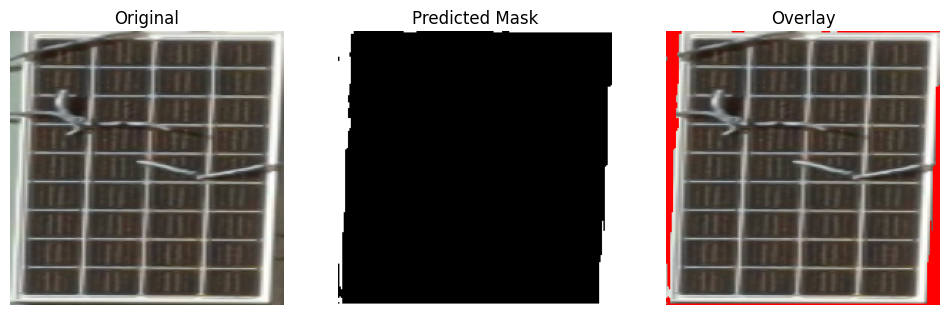

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick one test image
sample_img_path = test_df["image_path"].iloc[0]

# Load image
img = tf.io.read_file(sample_img_path)
img = tf.image.decode_png(img, channels=3)
img = tf.image.resize(img, (192,192))
img = tf.cast(img, tf.float32) / 255.0

# Predict mask
pred_mask = seg_model.predict(img[None,...])[0]
pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)

# Show
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(pred_mask_bin[:,:,0], cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
overlay = img.numpy().copy()
overlay[pred_mask_bin[:,:,0]==1] = [1,0,0]
plt.imshow(overlay)
plt.axis("off")

plt.show()

new approch of detect model

In [ ]:
!pip install ultralytics roboflow opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
import os

base_path = "/content/drive/MyDrive/project"

folders = [
    "datasets",
    "datasets/kaggle",
    "datasets/roboflow",
    "final_dataset"
]

for f in folders:
    os.makedirs(os.path.join(base_path, f), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="5kHA2nfkOv3Wi7iYlCm2")

project = rf.workspace("solarpaneldataset").project("solarpanel-ggmtm")

dataset = project.version(1).download("yolov8", location="/content/solar_project/datasets/roboflow")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/solar_project/datasets/roboflow in yolov8:: 100%|██████████| 3272/3272 [00:01<00:00, 1879.19it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os #to check the dataset

path = "/content/solar_project/datasets/roboflow"

for root, dirs, files in os.walk(path):
    print(root)

/content/solar_project/datasets/roboflow
/content/solar_project/datasets/roboflow/test
/content/solar_project/datasets/roboflow/test/images
/content/solar_project/datasets/roboflow/test/labels
/content/solar_project/datasets/roboflow/valid
/content/solar_project/datasets/roboflow/valid/images
/content/solar_project/datasets/roboflow/valid/labels
/content/solar_project/datasets/roboflow/train
/content/solar_project/datasets/roboflow/train/images
/content/solar_project/datasets/roboflow/train/labels


In [ ]:
classes = {
    "Clean": 0,
    "Dusty": 1,
    "Bird-drop": 2,
    "Electrical-damage": 3,
    "Physical-Damage": 4,
    "Snow-Covered": 5
}

import os

output_path = "/content/solar_project/final_dataset"

os.makedirs(f"{output_path}/images", exist_ok=True)
os.makedirs(f"{output_path}/labels", exist_ok=True)

In [ ]:
 import os

print(len(os.listdir("/content/solar_project/final_dataset/images")))

878


In [ ]:
import os

final_path = "/content/solar_project/solar_final"

folders = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels"
]

for f in folders:
    os.makedirs(os.path.join(final_path, f), exist_ok=True)

print("Final dataset ready!")

Final dataset ready!


In [ ]:
import shutil

rf_path = "/content/solar_project/datasets/roboflow"

# train
for file in os.listdir(f"{rf_path}/train/images"):
    shutil.copy(f"{rf_path}/train/images/{file}", f"{final_path}/train/images/{file}")

for file in os.listdir(f"{rf_path}/train/labels"):
    shutil.copy(f"{rf_path}/train/labels/{file}", f"{final_path}/train/labels/{file}")

# valid
for file in os.listdir(f"{rf_path}/valid/images"):
    shutil.copy(f"{rf_path}/valid/images/{file}", f"{final_path}/valid/images/{file}")

for file in os.listdir(f"{rf_path}/valid/labels"):
    shutil.copy(f"{rf_path}/valid/labels/{file}", f"{final_path}/valid/labels/{file}")

print("Roboflow merged!")

Roboflow merged!


In [ ]:
kaggle_img = "/content/solar_project/final_dataset/images"
kaggle_lbl = "/content/solar_project/final_dataset/labels"

for file in os.listdir(kaggle_img):
    shutil.copy(f"{kaggle_img}/{file}", f"{final_path}/train/images/{file}")

for file in os.listdir(kaggle_lbl):
    shutil.copy(f"{kaggle_lbl}/{file}", f"{final_path}/train/labels/{file}")

print("Kaggle merged!")

Kaggle merged!


In [ ]:
yaml_content = """
path: /content/solar_project/solar_final

train: train/images
val: valid/images

names:
  0: Clean
  1: Dusty
  2: Bird-drop
  3: Electrical-Damage
  4: Physical-Damage
  5: Snow-Covered
"""

with open("/content/solar_project/solar_final/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created!")

data.yaml created!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/solar_project/solar_final/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=15,
    save=True,
    project="/content/solar_project",
    name="solar_defect_model"
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/solar_project/solar_final/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=solar_defect_model2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/solar_project/solar_defect_model/weights/best.pt")

In [ ]:
results = model.predict(
    source="/content/solar_project/solar_final/valid/images",
    save=True,
    conf=0.25
)

In [ ]:
model.predict(
    source="/content/test.jpg",
    show=True,
    conf=0.25
)

In [ ]:
metrics = model.val()
print(metrics)

In [ ]:
import shutil

src = "/content/solar_project/solar_defect_model/weights/best.pt"
dst = "/content/drive/MyDrive/project/best.pt"

shutil.copy(src, dst)

print("Model saved to Drive!")


image 1/1 /content/Solar-Shine-Lichen-Blurb.jpg: 480x640 1 Clean, 8.1ms
Speed: 5.0ms preprocess, 8.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict2


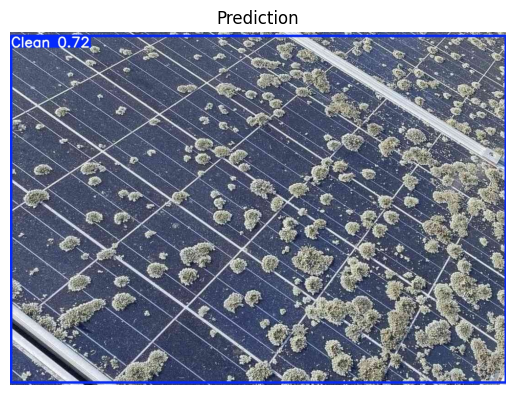

Class: Clean, Confidence: 0.72


In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os

# load model (only once)
model = YOLO("/content/drive/MyDrive/project/best.pt")

# 👉 CHANGE THIS PATH EVERY TIME
image_path = "/content/Solar-Shine-Lichen-Blurb.jpg"

# run prediction
results = model(image_path, save=True)

# get saved output image path
output_path = results[0].path  # original image path
save_dir = results[0].save_dir

# construct saved image path
filename = os.path.basename(image_path)
saved_image_path = os.path.join(save_dir, filename)

# show result image
img = Image.open(saved_image_path)

plt.imshow(img)
plt.title("Prediction")
plt.axis("off")
plt.show()

# print prediction details
class_names = model.names

for cls, conf in zip(results[0].boxes.cls, results[0].boxes.conf):
    print(f"Class: {class_names[int(cls)]}, Confidence: {float(conf):.2f}")



In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# load model
model = load_model("/content/drive/MyDrive/solar_project/power_loss_model.keras")

# load and preprocess image
img = image.load_img("/content/pysical.webp", target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# prediction
pred = model.predict(img_array)

print("Prediction:", pred)